In [1]:
# ============================================================
# Exploratory Data Analysis on House Price Dataset
# ============================================================
# Author: Proshanta Pal
# Dataset: House Price Dataset
# Date: 2026-05-13
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
# Load the Dataset
df = pd.read_csv('../data/raw/train.csv')
df.head() # Shows the first 5 rows

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,...,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,...,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,...,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,...,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# First look on the data
print(f"Shape of Dataset: {df.shape}")
rows, cols = df.shape
print(f"We have {rows} houses and {cols} features per house.")

Shape of Dataset: (1460, 81)
We have 1460 houses and 81 features per house.


## The five questions?

In [4]:
# 1. What columns do I have? What type is each one?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
# 1.1 Separate Numerical and Categorical Columns
numerical_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Numerical Columns: {len(numerical_cols)}")
print(f"Categorical Columns: {len(categorical_cols)}", end="\n\n")
print(f"Numerical Data: {numerical_cols}", end='\n\n')
print(f"Categorical Data: {categorical_cols}")

Numerical Columns: 38
Categorical Columns: 43

Numerical Data: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Categorical Data: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical

In [6]:
# 1.2 Find Numerical Columns that are actually Categorical
suspicious = []
for col in numerical_cols:
    unique_count = df[col].nunique() # Counts how many distinct values exist in this column
    if unique_count <= 15:
        unique_vals = sorted(df[col].unique().tolist())
        suspicious.append({
            'column': col,
            'unique_count': unique_count,
            'unique_values': unique_vals
        })

# Turn that list into a readable DataFrames
suspicious_df = pd.DataFrame(suspicious)
suspicious_df

,column,unique_count,unique_values
0,MSSubClass,15,"[20, 30, 40, 45, 50, 60, 70, 75, 80, 85, 90, 1..."
1,OverallQual,10,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
2,OverallCond,9,"[1, 2, 3, 4, 5, 6, 7, 8, 9]"
3,BsmtFullBath,4,"[0, 1, 2, 3]"
4,BsmtHalfBath,3,"[0, 1, 2]"
5,FullBath,4,"[0, 1, 2, 3]"
6,HalfBath,3,"[0, 1, 2]"
7,BedroomAbvGr,8,"[0, 1, 2, 3, 4, 5, 6, 8]"
8,KitchenAbvGr,4,"[0, 1, 2, 3]"
9,TotRmsAbvGrd,12,"[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14]"


In [7]:
# 2. Is any data missing?
missing_count = df.isnull().sum() 
missing_count = missing_count[missing_count > 0] # Keep only columns that actually have missing values
missing_pct = (missing_count / len(df) * 100).round(2) # Calculate what percentage of rows are missing

missing_df = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_pct
})
missing_df = missing_df.sort_values('missing_percent', ascending=False)
missing_df

,missing_count,missing_percent
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


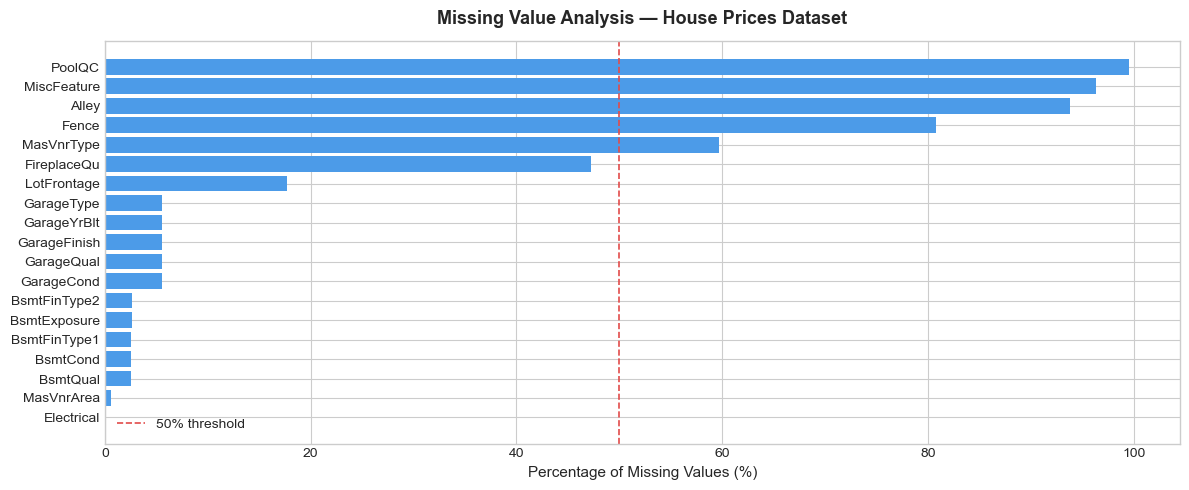

In [8]:
# 2.1 Visualizing the Missing Data
fig, ax = plt.subplots(figsize=(12, 5))

ax.barh(
    y = missing_df.index,
    width = missing_df['missing_percent'],
    color = '#4C9BE8'
)

# Columns above 50% missing are usually candidates for dropping
ax.axvline(x=50, color='#E24B4A', linestyle='--', linewidth=1.2, label='50% threshold')
ax.set_xlabel('Percentage of Missing Values (%)', fontsize=11)
ax.set_title('Missing Value Analysis — House Prices Dataset', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10)
ax.invert_yaxis()
plt.tight_layout()

# Save it to our reports
plt.savefig('../reports/figures/01_missing_values.png')
plt.show()

In [9]:
# 2.2 Classify Missing Value Reasons
# We document our understanding of WHY data is missing
missing_analysis = {
    # Format: 'column' : ('reason', 'action')

    'PoolQC'     : ('Does not exist — house has no pool', 'Fill with "None"'),
    'MiscFeature': ('Does not exist — no misc feature', 'Fill with "None"'),
    'Alley'      : ('Does not exist — no alley access', 'Fill with "None"'),
    'Fence'      : ('Does not exist — no fence', 'Fill with "None"'),
    'MasVnrType' : ('Mixed — investigate further', 'Fill with "None", revisit in FE'),
    'FireplaceQu': ('Does not exist — no fireplace', 'Fill with "None"'),
    'LotFrontage': ('True missing — not recorded', 'Impute with neighbourhood median'),
    'GarageType' : ('Does not exist — no garage', 'Fill with "None"'),
}

print(f"{'Column':<15} {'Reason':<45} {'Planned Action'}")
print("-" * 85)
for col, (reason, action) in missing_analysis.items():
    print(f"{col:<15} {reason:<45} {action}")

Column          Reason                                        Planned Action
-------------------------------------------------------------------------------------
PoolQC          Does not exist — house has no pool            Fill with "None"
MiscFeature     Does not exist — no misc feature              Fill with "None"
Alley           Does not exist — no alley access              Fill with "None"
Fence           Does not exist — no fence                     Fill with "None"
MasVnrType      Mixed — investigate further                   Fill with "None", revisit in FE
FireplaceQu     Does not exist — no fireplace                 Fill with "None"
LotFrontage     True missing — not recorded                   Impute with neighbourhood median
GarageType      Does not exist — no garage                    Fill with "None"


In [10]:
# 3. What do the Numbers look like? 
# Summary Statistics for Numerical Columns
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.50,421.61,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.90,42.30,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.05,24.28,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.83,9981.26,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.10,1.38,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.58,1.11,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.27,30.20,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.87,20.65,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.69,181.07,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.64,456.10,0.0,0.00,383.5,712.25,5644.0


In [11]:
# Automatically Flag Skewed Numerical Columns
# Skewness measures how lopsided a distribution is
# 0    = perfectly symmetric (bell curve)
# > 1  = moderately right-skewed (long tail on the right)
# > 2  = highly skewed; needs attention before modelling

skewness = df[numerical_cols].skew().sort_values(ascending=False) # .skew() computes skewness for every numerical columns at once
high_skew = skewness[abs(skewness) > 1] # Only care about columns with higher skewness (above 1 or below -1)
print(f"Columns with high skewness (|skew| > 1): {len(high_skew)}")
high_skew.round(2)

Columns with high skewness (|skew| > 1): 20


MiscVal          24.48
PoolArea         14.83
LotArea          12.21
3SsnPorch        10.30
LowQualFinSF      9.01
KitchenAbvGr      4.49
BsmtFinSF2        4.26
ScreenPorch       4.12
BsmtHalfBath      4.10
EnclosedPorch     3.09
MasVnrArea        2.67
OpenPorchSF       2.36
LotFrontage       2.16
SalePrice         1.88
BsmtFinSF1        1.69
WoodDeckSF        1.54
TotalBsmtSF       1.52
MSSubClass        1.41
1stFlrSF          1.38
GrLivArea         1.37
dtype: float64

## Visualizing Distributions

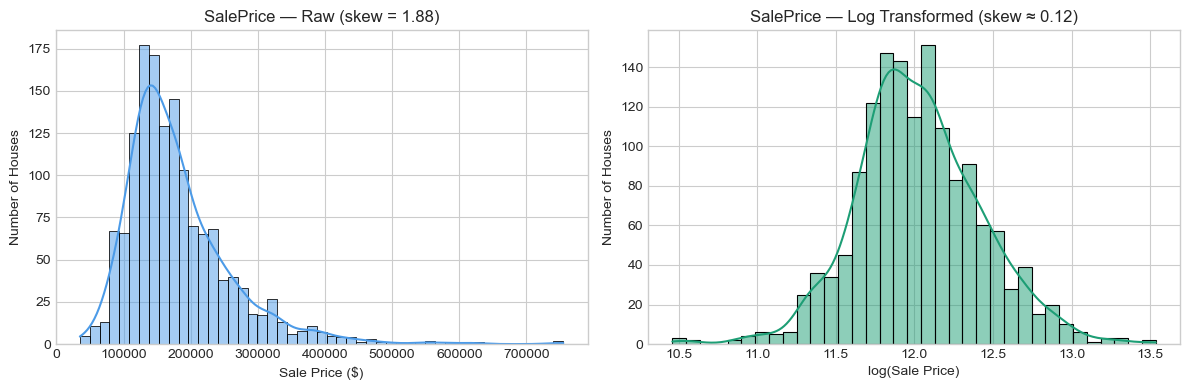

In [12]:
# SalesPrice Distribution

# This lets us compare raw vs log-transformed in one glance
fig, axes = plt.subplots(nrows= 1, ncols= 2, figsize= (12, 4))

# Left plot: Raw SalePrice
# histplot draws a histogram (bar chart of value frequencies)
# kde=True overlays a smooth curve on top of the bars
sns.histplot(data   = df['SalePrice'], kde=True, color='#4C9BE8',ax= axes[0])
axes[0].set_title('SalePrice — Raw (skew = 1.88)', fontsize=12)
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Number of Houses')

#Right plot: Log-transformed SalePrice 
# np.log1p means: log(1 + value)
# We use log1p instead of log because log(0) is undefined
# log1p handles zeros safely
sns.histplot(data   = np.log1p(df['SalePrice']),kde= True, color= '#1D9E75', ax= axes[1])
axes[1].set_title('SalePrice — Log Transformed (skew ≈ 0.12)', fontsize=12)
axes[1].set_xlabel('log(Sale Price)')
axes[1].set_ylabel('Number of Houses')
plt.tight_layout()

plt.savefig('../reports/figures/02_saleprice_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

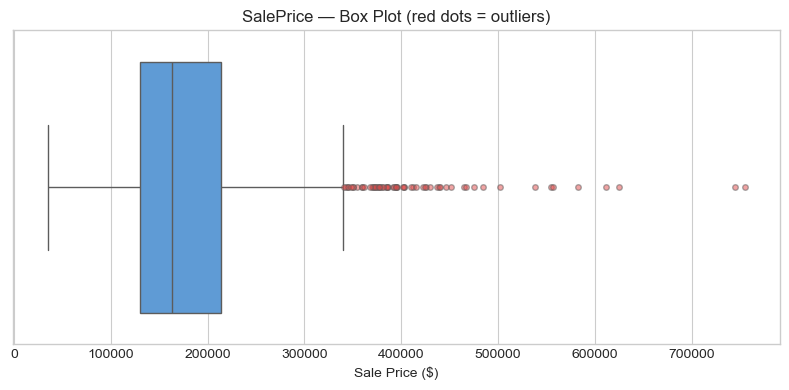

Q1            : $129,975
Q3            : $214,000
IQR           : $84,025
Lower bound   : $3,938
Upper bound   : $340,038
Outlier count : 61 houses
Outlier %     : 4.2%


In [13]:
# Boxplot for Outlier Detection
fig, ax = plt.subplots(figsize=(8, 4))

sns.boxplot(x= df['SalePrice'], color= '#4C9BE8', ax= ax, flierprops = dict(marker= 'o',markerfacecolor= '#E24B4A',markersize= 4, alpha= 0.5))
ax.set_title('SalePrice — Box Plot (red dots = outliers)', fontsize=12)
ax.set_xlabel('Sale Price ($)')

plt.tight_layout()
plt.savefig('../reports/figures/03_saleprice_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# Calculate the exect outlier boundary
Q1  = df['SalePrice'].quantile(0.25) # lower quarter
Q3  = df['SalePrice'].quantile(0.75) # upper quarter
IQR = Q3 - Q1 # interquartile range

# The standard rule: anything beyond 1.5×IQR is an outlier
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count how many houses fall outside these bounds
outliers = df[
    (df['SalePrice'] < lower_bound) |
    (df['SalePrice'] > upper_bound)
]

print(f"Q1            : ${Q1:,.0f}")
print(f"Q3            : ${Q3:,.0f}")
print(f"IQR           : ${IQR:,.0f}")
print(f"Lower bound   : ${lower_bound:,.0f}")
print(f"Upper bound   : ${upper_bound:,.0f}")
print(f"Outlier count : {len(outliers)} houses")
print(f"Outlier %     : {len(outliers)/len(df)*100:.1f}%")

In [14]:
# Correlation of All Features with SalePrice

# Compute correlation of every numerical column with SalePrice
# .corr() computes pairwise correlation between all numerical columns
# We then extract only the 'SalePrice' row and sort it
saleprice_corr = (
    df[numerical_cols] # take only numerical columns
    .corr() # compute full correlation matrix
    ['SalePrice'] # extract the SalePrice column
    .drop('SalePrice')# remove SalePrice vs itself (always 1.0)
    .sort_values(ascending=False) # strongest first
)

print("Top 10 positively correlated features:")
print(saleprice_corr.head(10).round(3))
print("Top 5 negatively correlated features:")
print(saleprice_corr.tail(5).round(3))

Top 10 positively correlated features:
OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
YearRemodAdd    0.507
Name: SalePrice, dtype: float64
Top 5 negatively correlated features:
YrSold          -0.029
OverallCond     -0.078
MSSubClass      -0.084
EnclosedPorch   -0.129
KitchenAbvGr    -0.136
Name: SalePrice, dtype: float64


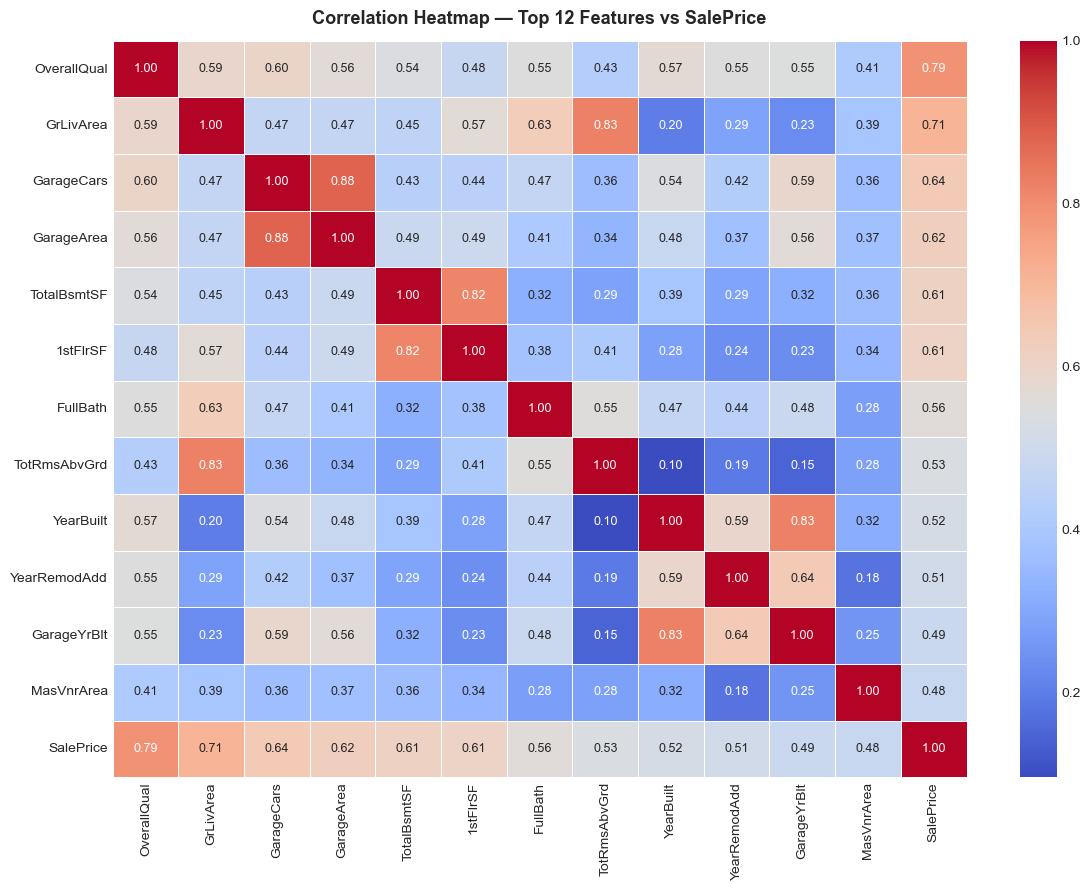

In [15]:
# Correlation Heatmap (Top Features Only)

# Step 1: Pick the top 12 correlated features + SalePrice
# We limit to 12 because a heatmap with 38 columns is unreadable
top_features = saleprice_corr.head(12).index.tolist()
top_features = top_features + ['SalePrice'] # add target column

# Step 2: Build the correlation matrix for just these columns
corr_matrix = df[top_features].corr()

# Step 3: Create the heatmap
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, annot= True, fmt= '.2f', cmap= 'coolwarm', linewidths= 0.5, ax= ax, annot_kws= {'size': 9})
ax.set_title('Correlation Heatmap — Top 12 Features vs SalePrice', fontsize= 13, fontweight= 'bold', pad= 12)

plt.tight_layout()
plt.savefig('../reports/figures/04_correlation_heatmap.png',dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Detect Multicollinear Feature Pairs

# Step 1: Build the full correlation matrix
corr_matrix = df[numerical_cols].corr().abs()  # .abs() → ignore sign

# Step 2: Take only the upper triangle of the matrix
# The matrix is symmetric - top-right = bottom-left
# So we only need half of it to avoid duplicates
# triu = upper triangle mask
# k=1 skips the diagonal (self-correlation)
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Step 3: Find pairs with correlation above our threshold
threshold = 0.80

high_corr_pairs = []

for col in upper_triangle.columns:
    for row in upper_triangle.index:
        val = upper_triangle.loc[row, col]
        if pd.notna(val) and val >= threshold:
            high_corr_pairs.append({
                'feature_1'  : row,
                'feature_2'  : col,
                'correlation': round(val, 3)
            })

# Step 4: Display results sorted by strongest correlation first
pairs_df = (
    pd.DataFrame(high_corr_pairs)
    .sort_values('correlation', ascending=False)
    .reset_index(drop=True)
)

print(f"Feature pairs with correlation >= {threshold}:")
print(pairs_df.to_string(index=False))

Feature pairs with correlation >= 0.8:
  feature_1    feature_2  correlation
 GarageCars   GarageArea        0.882
  YearBuilt  GarageYrBlt        0.826
  GrLivArea TotRmsAbvGrd        0.825
TotalBsmtSF     1stFlrSF        0.820
